In [1]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

In [2]:
# System of three nonlinear equations
def prob2(c, tau):
    # Parameters
    k1 = 1.0   # 1/min
    k2 = 0.1   # 1/min
    ca0 = 1.0  # mol/L

    # Equations
    eq1 = (ca0 - c[0])/tau - 2*k1*c[0]**2
    eq2 = -c[1]/tau + k1*c[0]**2 - k2*c[1]
    eq3 = -c[2]/tau + k2*c[1]
    return [eq1, eq2, eq3]

# Part (a)
print('- Part (a):')
c_a, _, _, mesg = fsolve(prob2, [1, 1, 1], args=(0.5,), xtol=1e-8, full_output=True)
print("Convergence message:", mesg)
print("Solution for part (a):", np.round(c_a, 3))

- Part (a):
Convergence message: The solution converged.
Solution for part (a): [0.618 0.182 0.009]


In [3]:
# Part (b)
print()
print('- Part (b):')
i = 0
c0_b = [1, 1, 1]
tau = np.arange(0.1, 20, 0.01)
c_b = np.zeros((len(tau), 3))

for taui in tau:
    c_b[i, :] = fsolve(prob2, c0_b, args=(taui,), xtol=1e-8)
    c0_b = c_b[i, :]
    i += 1

# Compute maximum value and corresponding residence time
max_B = np.max(c_b[:, 1])
pos_B = np.argmax(c_b[:, 1])
tau_max_B = tau[pos_B]

print("Maximum concentration of B:", round(max_B, 3))
print("Residence time at maximum:", round(tau_max_B, 2), "minutes.")


- Part (b):
Maximum concentration of B: 0.257
Residence time at maximum: 2.68 minutes.


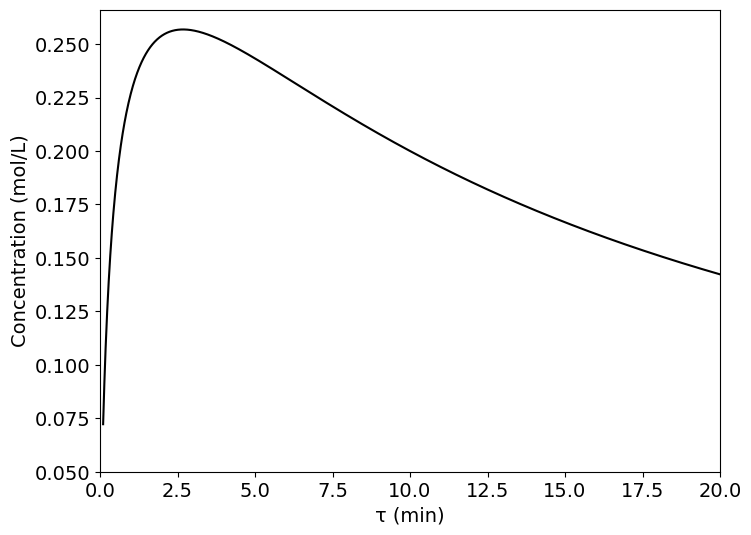

In [4]:
# Plot for part (b)
plt.figure(figsize=(8, 6))
plt.plot(tau, c_b[:, 1], 'k')
plt.xlabel('τ (min)', fontsize=14)
plt.xlim(0, 20)
plt.ylabel('Concentration (mol/L)', fontsize=14)
plt.ylim(0.05,)
plt.tick_params(axis='both', labelsize=14)

plt.show()